In [1]:
import numpy as np
import scipy.optimize as opt
from scipy.stats import poisson
import matplotlib.pyplot as plt

# veri seti
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

print("Veri seti:", traffic_data)
print("Gozlem sayisi:", len(traffic_data))
print("Toplam arac sayisi:", np.sum(traffic_data))

Veri seti: [12 15 10  8 14 11 13 16  9 12 11 14 10 15]
Gozlem sayisi: 14
Toplam arac sayisi: 170


# Bölüm 2 - MLE

Poisson dağılımı için negatif log-likelihood fonksiyonu yazılıp ve scipy.optimize ile minimum yapan lambda değeri bulunmuştur.

In [2]:
def negative_log_likelihood(lam, data):
    """
    Poisson dagilimi icin negatif log-likelihood hesaplar.

    Not:
    log(k!) terimi lambda'ya bagli olmadigi icin optimizasyonda sabit kabul
    edilir ve ihmal edilebilir.
    """
    lam = float(np.atleast_1d(lam)[0])

    # poisson parametresi pozitif olmali
    if lam <= 0:
        return np.inf

    n = len(data)
    sum_k = np.sum(data)

    # 
    # negatif log-likelihood minimizasyonda kullanilir
    nll = n * lam - sum_k * np.log(lam)
    return nll

In [3]:
def estimate_lambda_numerical(data, initial_guess=1.0):
    """NLL fonksiyonunu minimize ederek sayisal lambda tahmini yapar."""
    result = opt.minimize(
        negative_log_likelihood,
        x0=np.array([initial_guess]),
        args=(data,),
        bounds=[(0.001, None)],
        method="L-BFGS-B",
    )
    return result


# analitik cozum (verilerin ortalaması)
lambda_analytic = np.mean(traffic_data)

# numerik cozum (minimal negatif log-likelihood fonksiyonu)
result = estimate_lambda_numerical(traffic_data, initial_guess=1.0)
lambda_numerical = result.x[0]

print("=== ORIJINAL VERI SETI ===")
print(f"Analitik tahmin (ortalama): {lambda_analytic:.6f}")
print(f"Sayisal tahmin (MLE lambda): {lambda_numerical:.6f}")
print(f"Minimum NLL degeri: {result.fun:.6f}")
print(f"Optimizasyon basarili mi?: {result.success}")

=== ORIJINAL VERI SETI ===
Analitik tahmin (ortalama): 12.142857
Sayisal tahmin (MLE lambda): 12.142859
Minimum NLL degeri: -254.445988
Optimizasyon basarili mi?: True


# Bölüm 3 - Grafik

Bulunan lambda değeri ile Poisson PMF çizilip ve gerçek veri histogramı ile karşılaştırılmıştır.

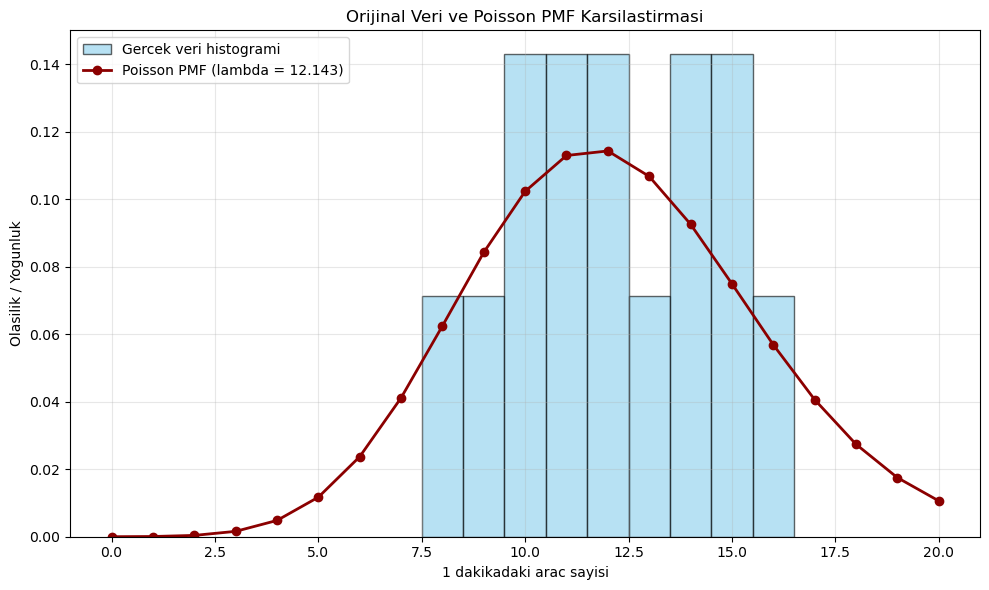

In [4]:
def plot_histogram_and_pmf(data, lam, title):
    """Veri histogramini ve Poisson PMF egrisini ayni grafikte cizer."""
    x_values = np.arange(0, max(data) + 5)
    pmf_values = poisson.pmf(x_values, mu=lam)

    plt.figure(figsize=(10, 6))

    # ayrik veri oldugu icin histogram kutulari tam sayi merkezli secilir
    bins = np.arange(data.min(), data.max() + 2) - 0.5
    plt.hist(
        data,
        bins=bins,
        density=True,
        alpha=0.6,
        color="skyblue",
        edgecolor="black",
        label="Gercek veri histogrami",
    )
    plt.plot(
        x_values,
        pmf_values,
        "o-",
        color="darkred",
        linewidth=2,
        label=f"Poisson PMF (lambda = {lam:.3f})",
    )

    plt.xlabel("1 dakikadaki arac sayisi")
    plt.ylabel("Olasilik / Yogunluk")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_histogram_and_pmf(
    traffic_data,
    lambda_numerical,
    "Orijinal Veri ve Poisson PMF Karsilastirmasi",
)

# Bölüm 4 - Outlier Analizi

In [5]:
# aykiri gozlem 
traffic_data_outlier = np.append(traffic_data, 200)

lambda_analytic_outlier = np.mean(traffic_data_outlier)
result_outlier = estimate_lambda_numerical(traffic_data_outlier, initial_guess=1.0)
lambda_numerical_outlier = result_outlier.x[0]

print("=== OUTLIER EKLENMIS VERI SETI ===")
print("Yeni veri seti:", traffic_data_outlier)
print(f"Analitik tahmin (ortalama): {lambda_analytic_outlier:.6f}")
print(f"Sayisal tahmin (MLE lambda): {lambda_numerical_outlier:.6f}")
print(f"Optimizasyon basarili mi?: {result_outlier.success}")

=== OUTLIER EKLENMIS VERI SETI ===
Yeni veri seti: [ 12  15  10   8  14  11  13  16   9  12  11  14  10  15 200]
Analitik tahmin (ortalama): 24.666667
Sayisal tahmin (MLE lambda): 24.666679
Optimizasyon basarili mi?: True


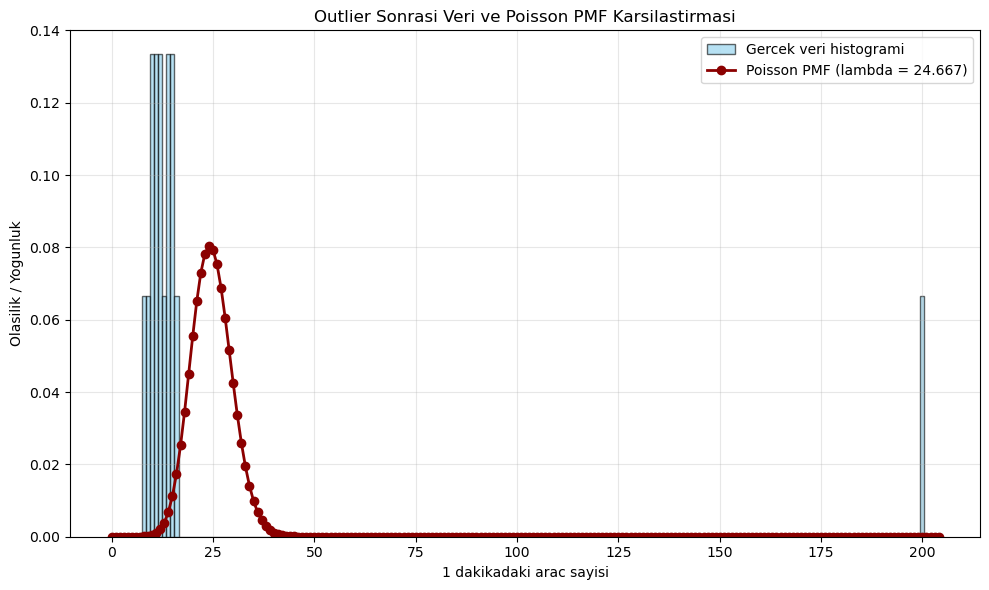

In [6]:
plot_histogram_and_pmf(
    traffic_data_outlier,
    lambda_numerical_outlier,
    "Outlier Sonrasi Veri ve Poisson PMF Karsilastirmasi",
)

Tek bir 200 değerli aykırı gözlem, lambda tahminini ciddi biçimde yukarı çekmiştir. Bu durum MLE'nin ortalamaya eşit olması nedeniyle aykırı değerlere hassas olduğunu gösterir.